In [3]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [4]:
torch.backends.mkldnn.enabled = True

In [5]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [6]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 32 → 16

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 16 → 8

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 120, 3, padding=1, groups=60),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    # nn.Conv2d(120, 120, 1),   # pointwise conv
    # nn.BatchNorm2d(120),
    # nn.PReLU(),

    nn.Conv2d(120, 120, 3, padding=1, groups=120),
    nn.BatchNorm2d(120),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 8 → 4

    # nn.Conv2d(120, 120, 1),   # pointwise conv
    # nn.BatchNorm2d(120),
    # nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(120, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 4 → 2

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [7]:
model14_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model14_0)
describe(model14_0)

MACs: 4.33 MMac, Params: 26.55 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model14_0.pt
Starting
Epoch 1/60: Train loss = 1.1050, Train accuracy = 0.6051, Test loss = 1.0784, Test accuracy = 0.6161
Epoch 2/60: Train loss = 0.9844, Train accuracy = 0.6477, Test loss = 0.9605, Test accuracy = 0.6594
Epoch 3/60: Train loss = 0.9203, Train accuracy = 0.6776, Test loss = 0.9383, Test accuracy = 0.6696
Epoch 4/60: Train loss = 0.9013, Train accuracy = 0.6814, Test loss = 0.8870, Test accuracy = 0.6904
Epoch 5/60: Train loss = 0.7716, Train accuracy = 0.7310, Test loss = 0.8188, Test accuracy = 0.7224
Epoch 6/60: Train loss = 0.6698, Train accuracy = 0.7639, Test loss = 0.6722, Test accuracy = 0.7679
Epoch 7/60: Train loss = 0.6942, Train accuracy = 0.7543, Test loss = 0.6981, Test accuracy = 0.7560
Epoch 8/60: Train loss = 0.6180, Train accuracy = 0.7850, Test loss = 0.6421, Test accuracy = 0.7786
Epoch 9/60: Train loss = 0.7143, Train accuracy = 0.7521, Test loss = 0.7280, Test accuracy = 0.7514
Epoch 10/60: Train loss = 0.617

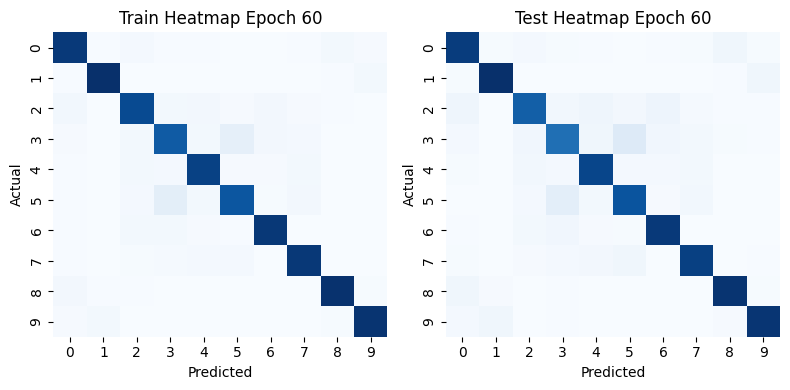

<Figure size 1200x600 with 0 Axes>

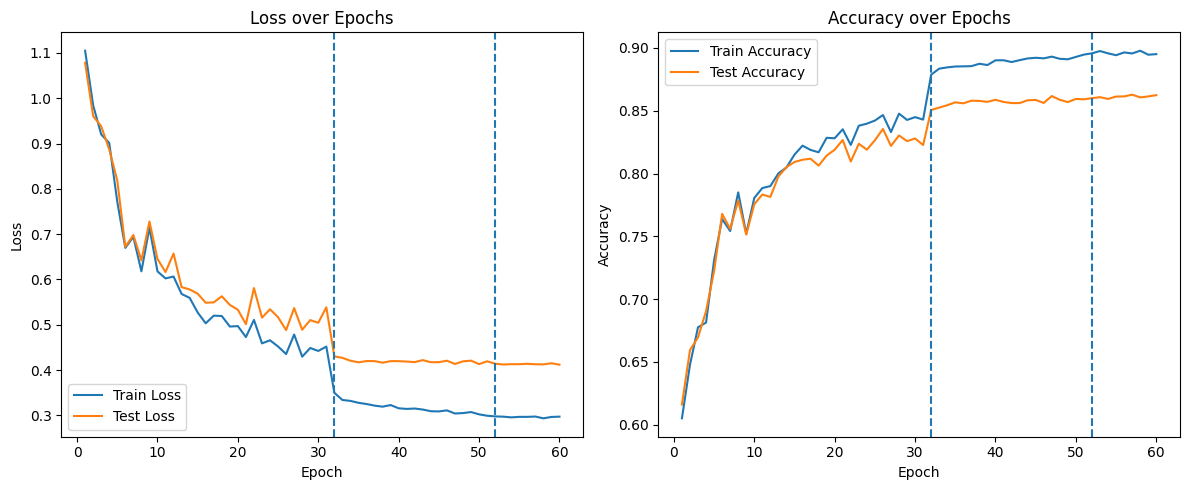

In [8]:
trainf32(model14_0,"model_weights/model14_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [9]:
model14_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model14_1)
describe(model14_1)

MACs: 4.33 MMac, Params: 26.55 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Starting
Epoch 1/60: Train loss = 1.0509, Train accuracy = 0.6249, Test loss = 1.0371, Test accuracy = 0.6360
Epoch 2/60: Train loss = 0.9241, Train accuracy = 0.6803, Test loss = 0.8895, Test accuracy = 0.6976
Epoch 3/60: Train loss = 0.8778, Train accuracy = 0.6954, Test loss = 0.8832, Test accuracy = 0.7045
Epoch 4/60: Train loss = 0.7565, Train accuracy = 0.7345, Test loss = 0.7592, Test accuracy = 0.7391
Epoch 5/60: Train loss = 0.7118, Train accuracy = 0.7525, Test loss = 0.7440, Test accuracy = 0.7484
Epoch 6/60: Train loss = 0.6127, Train accuracy = 0.7840, Test loss = 0.6357, Test accuracy = 0.7847
Epoch 7/60: Train loss = 0.6733, Train accuracy = 0.7642, Test loss = 0.7178, Test accuracy = 0.7564
Epoch 8/60: Train loss = 0.6185, Train accuracy = 0.7817, Test loss = 0.6498, Test accuracy = 0.7681
Epoch 9/60: Train loss = 0.6293, Train accuracy = 0.7784, Test loss = 0.6661, Test accuracy = 0.7690
Epoch 10/60: Train loss = 0.5778, Train accuracy = 0.7989, Test loss = 0.6262, Tes

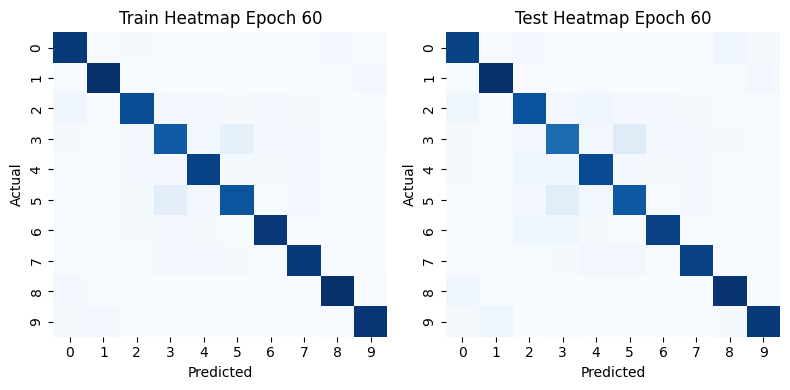

<Figure size 1200x600 with 0 Axes>

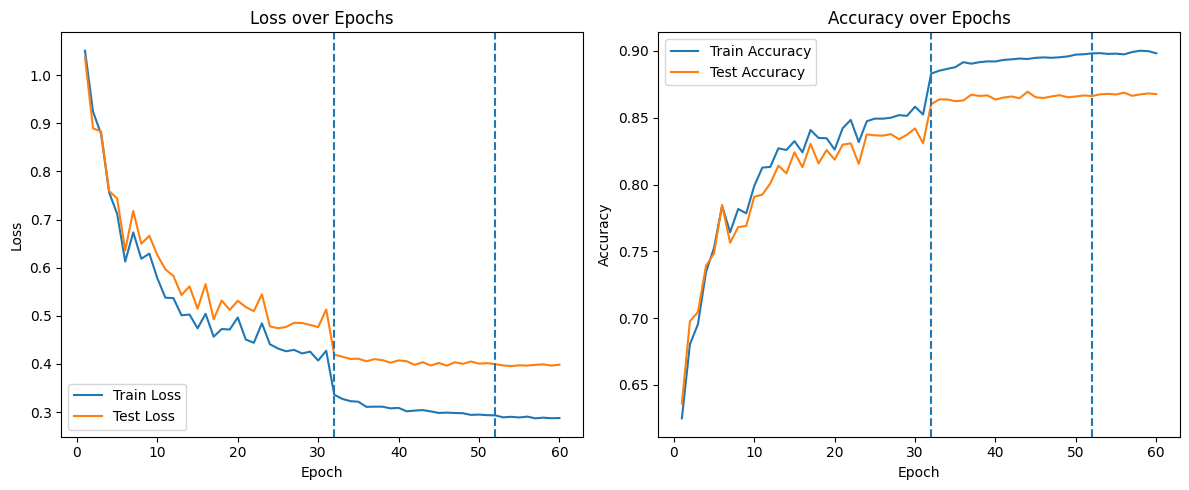

In [ ]:
trainf32(model14_1,"model_weights/model14_1.pt",criterion,train_dataset,val_dataset, batch_size=64)